In [76]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import det as det
from scipy.linalg import cholesky, qr, rq, solve_triangular
from scipy.special import gammaln, digamma
from scipy.optimize import minimize
from mpl_toolkits.mplot3d import Axes3D
from scipy.special import digamma
from scipy.optimize import root_scalar
from scipy.optimize import least_squares
from itertools import combinations

In [97]:
row1  = [18, 18, 19, 19.2, 15, 19.2, 16, 18.5, 19, 19, 17.5, 19, 19]
row2  = [70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70]
row3  = [22, 45, 68, 40, 95, 56, 125, 56, 38, 25, 95, 60, 60]
row4  = [120, 120, 120, 120, 120, 120, 120, 120, 120, 150, 120, 120, 120]
row5  = [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
row6  = [1, 1, 1, 2, 2, 2, 2, 2, 3, 1, 4, 4, 4]
row7  = [6.90E-06, 4.90E-06, 6.30E-06, 7.50E-06, 6.90E-06, 6.10E-06, 4.80E-06, 6.20E-06, 6.30E-06, 2.80E-05, 5.50E-06, 5.40E-06, 5.60E-06]
row8  = [9.1E-5, 7.10E-05, 6.5E-05, 7.10E-05, 7.10E-05, 7.00E-05, 7.00E-05, 7.50E-05, 8.00E-05, 8.00E-05, 8.00E-05, 8.00E-05, 8.00E-05]
row9  = [3.8, 3.6, 3.8, 3.8, 3.8, 3.8, 4, 4, 4, 4, 4, 4, 4]
row10 = [1, 2, 2, 3, 4, 4, 5, 5, 7, 8, 2, 2, 2]
row11 = [1300, 1100, 900, 750, 230, 2.3, 2.5, 3, 3, 3, 3, 3, 3]
row12 = [10, 2, 8, 3, 1, 3, 2, 5, 9, 9, 9, 9, 9]


# Separate into categorized (g), continuous (z), and response (y)
g_data = np.array([row1, row2, row3, row4, row5, row6, row9, row10])
z_data = np.array([row7, row8])
y_data = np.array(row12)

l_g = g_data.shape[0]  # Number of categorical variables
l_z = 3  # 2 continuous variables + 1 intercept
n = 1    # Response dimension
w = 1.0 / l_g  # Uniform weighting for mixing

In [36]:
def get_upper_G(V, label=""):
  """
  safely decomposes V into GG^T
  """
  eigvals = np.linalg.eigvalsh(V)
  if eigvals.min() < 1e-10:
      V = V + np.eye(len(V)) * (1e-10 - eigvals.min())
  try:
      L = np.linalg.cholesky(V)
  except np.linalg.LinAlgError:
      print(f"[get_upper_G{' '+label if label else ''}] Cholesky failed, eigvals: {eigvals}")
      raise
  R, _ = rq(L, mode='economic')
  signs = np.sign(np.diag(R))
  signs[signs == 0] = 1.0
  return R * signs.reshape(-1, 1)

def J_derivatives(nu, G, l_z, n=1, label=""):
  """
  Calculates derivatives of the normalizing constant J with respect to nu and V
  """
  Gyy = G[:n, :n]
  Gzz = G[n:, n:]

  try:
      inv_Gzz = np.linalg.inv(Gzz)
  except np.linalg.LinAlgError:
      print(f"[J_derivatives{' '+label if label else ''}] Gzz singular:\n{Gzz}")
      raise
  inv_V_z = inv_Gzz.T @ inv_Gzz

  Lambda = Gyy @ Gyy.T
  if np.any(Lambda <= 0):
      print(f"[J_derivatives{' '+label if label else ''}] Lambda non-positive: {Lambda}")

  try:
      inv_G = np.linalg.inv(G)
  except np.linalg.LinAlgError:
      print(f"[J_derivatives{' '+label if label else ''}] G singular:\n{G}")
      raise
  inv_V = inv_G.T @ inv_G

  pad_inv_V_z = np.zeros_like(G)
  pad_inv_V_z[n:, n:] = inv_V_z

  dnu = -0.5 * np.log(np.abs(Lambda)) + 0.5 * np.log(2) + 0.5 * digamma(0.5 * (nu - l_z + 2))
  dV  = 0.5 * (nu - l_z + 1) * pad_inv_V_z - 0.5 * (nu - l_z + 2) * inv_V
  return dnu, dV

def solver_for_V(m, M, l_z, n=1):
    dim = l_z + n
    n_tri = dim * (dim + 1) // 2

    def unpack(params):
        nu = (l_z - 2.0 + 0.01) + np.exp(params[0])
        L = np.zeros((dim, dim))
        idx = 1
        for i in range(dim):
            for j in range(i + 1):
                if i == j:
                    L[i, j] = np.exp(params[idx])
                else:
                    L[i, j] = params[idx]
                idx += 1
        return nu, L

    def residuals(params):
        nu, L = unpack(params)
        V = L @ L.T
        G = get_upper_G(V, label="residuals")
        dnu, dV = J_derivatives(nu, G, l_z, n, label="residuals")
        r_nu = (dnu - m).ravel()
        r_V  = (dV - M).ravel()
        return np.concatenate([r_nu, r_V])

    nu_init = float(l_z + n + 1.0)
    V_init  = np.eye(dim) * 1e-3
    L_init  = np.linalg.cholesky(V_init)

    params0    = np.zeros(1 + n_tri)
    params0[0] = np.log(nu_init - (l_z - 2.0 + 0.01))
    idx = 1
    for i in range(dim):
        for j in range(i + 1):
            if i == j:
                params0[idx] = np.log(L_init[i, j])
            else:
                params0[idx] = L_init[i, j]
            idx += 1

    result = least_squares(residuals, params0, method='lm',
                           ftol=1e-10, xtol=1e-10, gtol=1e-10,
                           max_nfev=10000)

    nu_opt, L_opt = unpack(result.x)
    V_opt = L_opt @ L_opt.T

    print(f"[nu, V] solver cost: {result.cost:.2e}, "
          f"success: {result.success}, message: {result.message}")
    print(f"  nu_opt={nu_opt:.4f}, V_opt eigvals: {np.linalg.eigvalsh(V_opt)}")

    eigvals = np.linalg.eigvalsh(V_opt)
    if eigvals.min() < 1e-10:
        V_opt += np.eye(dim) * (1e-10 - eigvals.min())

    return nu_opt, get_upper_G(V_opt, label="final")

def exact_moment_matching(m, M, l_z, n=1):
    M_y  = M[:n, :n]
    M_yz = M[:n, n:]
    M_z  = M[n:, n:]

    # --- Step 1: solve for x = 0.5*(nu - l_z + 2) ---
    det_My = np.linalg.det(-2.0 * M_y)
    C = 2.0 * float(m) - np.log(max(det_My, 1e-12))
    C = min(C, -1e-10)

    def f(x):
        return digamma(x) - np.log(x) - C

    a, b = 0.5001, 1.0
    while f(a) * f(b) > 0 and b < 1e8:
        a, b = b, b * 10.0
    try:
        x = root_scalar(f, bracket=[a, b], method='brentq').root
    except:
        x = a

    nu_opt = 2.0 * x + l_z - 2.0

    # --- Step 2: P = V_yz V_z^{-1}, exact and independent of x ---
    inv_My = np.linalg.inv(M_y)
    P = inv_My @ M_yz

    # --- Step 3: V_z from Schur complement, exact and independent of x ---
    M_schur = M_z - M_yz.T @ inv_My @ M_yz
    # Ensure negative definite before inversion
    vals, vecs = np.linalg.eigh(M_schur)
    vals = np.minimum(vals, -1e-10)
    M_schur = vecs @ np.diag(vals) @ vecs.T
    V_z_opt = np.linalg.inv(-2.0 * M_schur)

    # --- Step 4: assemble V ---
    Lambda  = -x * inv_My
    V_yz_opt = P @ V_z_opt
    V_y_opt  = Lambda + P @ V_z_opt @ P.T

    V_opt = np.zeros((l_z + n, l_z + n))
    V_opt[:n, :n] = V_y_opt
    V_opt[:n, n:] = V_yz_opt
    V_opt[n:, :n] = V_yz_opt.T
    V_opt[n:, n:] = V_z_opt
    V_opt = 0.5 * (V_opt + V_opt.T) + np.eye(l_z + n) * 1e-11

    return nu_opt, get_upper_G(V_opt)

In [37]:
def log_J(nu, G, l_z, n=1):
    Gyy = G[:n, :n]
    Gzz = G[n:, n:]
    log_det_Lambda = 2.0 * np.sum(np.log(np.abs(np.diag(Gyy))))
    log_det_Vz     = 2.0 * np.sum(np.log(np.abs(np.diag(Gzz))))
    x = 0.5 * (nu - l_z + 2)
    return float(0.5 * l_z * np.log(2 * np.pi)
            - 0.5 * log_det_Vz
            - x * log_det_Lambda
            + x * np.log(2.0)
            + gammaln(x))

def predictive_log_likelihood(G, nu, y, z, l_z, n=1):
    d = np.concatenate([y, z])
    V_updated = G @ G.T + np.outer(d, d)
    G_updated = get_upper_G(V_updated)
    return float(log_J(nu + 1, G_updated, l_z, n) - log_J(nu, G, l_z, n))

In [38]:
def plot_F_surface(args, resolution=80):
    """
    Plots F(alpha,beta,gamma) over the simplex alpha+beta+gamma=1.
    """

    alpha_vals = np.linspace(1e-6, 1-1e-6, resolution)
    beta_vals  = np.linspace(1e-6, 1-1e-6, resolution)

    A, B = np.meshgrid(alpha_vals, beta_vals)
    F = np.full_like(A, np.nan)

    for i in range(resolution):
        for j in range(resolution):
            alpha = A[i, j]
            beta = B[i, j]
            gamma = 1 - alpha - beta

            if gamma > 0:  # inside simplex
                F[i, j] = func_F_phi(alpha, beta, gamma, args)

    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(A, B, F, linewidth=0, antialiased=True)

    ax.set_xlabel("alpha")
    ax.set_ylabel("beta")
    ax.set_zlabel("F(alpha,beta,gamma)")
    ax.set_title("Surface of F on simplex (gamma = 1 - alpha - beta)")

    plt.show()

In [50]:
def func_F_phi(alpha, beta, gamma, arguments):
    """
    Computes the function F(phi)
    """
    alpha_0, beta_0, gamma_0, delta_1, delta_0, gz, det_gz, gz_0, det_gz_0, gf, det_gf, gf_0, det_gf_0, V_t_1, V_t, V_0, L_t_1, L_t, L_0, zeta, kappa = arguments

    N = len(gf[0])
    rho = len(gz[0])

    detV_tilde = det(alpha*V_t_1 + beta*V_t + gamma*V_0)
    detL_tilde = det(alpha*L_t_1 + beta*L_t + gamma*L_0)
    delta_tilde = alpha*delta_1 + beta*(delta_1+1) + gamma*delta_0

    f = alpha*(np.log(alpha)-np.log(alpha_0)) + beta*(np.log(beta)-np.log(beta_0)) + gamma*(np.log(gamma)-np.log(gamma_0))
    s = 0
    for j in range(1, N+1):
        s += - gammaln((delta_tilde-rho+N+2-j)/2) + alpha*gammaln((delta_1-rho+N+2-j)/2) \
             + beta*gammaln((delta_1+1-rho+N+2-j)/2) + gamma*gammaln((delta_0-rho+N+2-j)/2)
    f += s
    f += -(alpha+beta)*N*np.log(det_gz) - beta*N/2*np.log(1+zeta) - gamma*N*np.log(det_gz_0) + N/2*np.log(detV_tilde)\
    - ((alpha+beta)*(delta_1-rho+N+1)+beta)*np.log(det_gf) - beta*((delta_1-rho+N+2)/2)*np.log(1+kappa/(1+zeta))\
    - gamma*(delta_0-rho+N+1)*np.log(det_gf_0) + (delta_tilde-rho+N+1)/2*np.log(detL_tilde)
    return f

def map_to_simplex(y):
    # y is length-2 array
    p1 = np.exp(y[0])
    p2 = np.exp(y[1])
    z = 1.0
    denom = p1 + p2 + z
    alpha = p1 / denom
    beta  = p2 / denom
    gamma = z  / denom
    return alpha, beta, gamma

def objective_y(y, args):
    alpha, beta, gamma = map_to_simplex(y)
    return func_F_phi(alpha, beta, gamma, args)

def opt_forget_factors(args):
    y0 = np.array([0.0, 0.0])
    res = minimize(objective_y, y0, args=(args,), method='Nelder-Mead', options={'maxiter': 2000, 'disp': False})
    y_opt = res.x
    alpha, beta, gamma = map_to_simplex(y_opt)
    return alpha, beta, gamma

def func_F_forecast(phi, phi0, y_hat, v_hat):
  """
  arg:
    phi: numpy array of mixing factors
    phi0: numpy array of prior mixing factors
    y_hat: numpy array of individual forecasts
    v_hat: numpy array of individual variances
  returns:
    F(phi) for forecast mixing
  """
  kl = 0
  for i in range(len(phi)):
    kl += phi[i]*(np.log(phi[i])-np.log(phi0[i]))
  f = 2*kl

  v = 1/np.sum(phi / v_hat)
  y = np.sum(y_hat * phi / v_hat)

  for i in range(len(phi)):
    f += phi[i]*y_hat[i]**2/v_hat[i] + phi[i]*np.log(v_hat[i])

  f += -np.log(v) - y**2*v

  return f

def opt_forecast_weights(y_hat, v_hat, phi0, n_restarts=200, seed=0):
    """
    Finds phi minimizing func_F_forecast subject to phi >= 0, sum(phi) = 1.
    Uses multiple random restarts with SLSQP to avoid local minima.
    """
    k     = len(y_hat)
    y_hat = np.array(y_hat, dtype=float)
    v_hat = np.array(v_hat, dtype=float)
    phi0  = np.array(phi0,  dtype=float)
    phi0  = phi0 / phi0.sum()
    rng   = np.random.default_rng(seed)

    def stable_objective(phi):
        # Clip inside objective so log never sees 0,
        # without blocking the optimizer from reaching boundaries
        phi_safe = np.clip(phi, 1e-300, 1.0)
        return func_F_forecast(phi_safe, phi0, y_hat, v_hat)

    constraints = {'type': 'eq', 'fun': lambda phi: np.sum(phi) - 1.0}
    bounds      = [(0.0, 1.0)] * k

    best_val    = np.inf
    best_phi    = phi0.copy()

    # Starting points: phi0, uniform, and random Dirichlet samples
    starts = [phi0, np.ones(k) / k]
    starts += [rng.dirichlet(np.ones(k)) for _ in range(n_restarts)]

    for phi_init in starts:
        phi_init = np.array(phi_init, dtype=float)
        phi_init = phi_init / phi_init.sum()
        try:
            result = minimize(stable_objective, phi_init,
                              method='SLSQP',
                              bounds=bounds,
                              constraints=constraints,
                              options={'ftol': 1e-12,
                                       'maxiter': 2000,
                                       'disp': False})
            if result.success and result.fun < best_val:
                best_val = result.fun
                best_phi = result.x
        except Exception:
            continue

    # Clean up numerical noise
    best_phi = np.clip(best_phi, 0.0, 1.0)
    best_phi /= best_phi.sum()
    return best_phi

In [40]:
def predict(gyz, gzz, regressor):
  """
  arg:
    gyz: Gyz
    gzz: Gzz
    regressor: regressor
  returns:
    forecast
  """
  P = gyz @ np.linalg.inv(gzz)
  y = P @ regressor
  return y

def get_variance(gyy, gzz, z, delta):
  """
  arg:
    gyy: Gyy
    gzz: Gzz
    z: regressor
    delta: counting statistics
  returns:
    estimated variance for this model
  """
  Lambda = gyy[0, 0]**2
  v_hat = Lambda / (delta) * (1.0 + z.T @ np.linalg.inv(gzz @ gzz.T) @ z)
  return v_hat

def update_G(G_prev, G_init, d, alpha, beta, gamma):
  """
  Updates the sufficent statistics matrix with forgetting phi
  GG' = (alpha+beta)*G_G_' + beta*dd' + gamma*G0G0'
  arg:
    G_prev: previous statistics matrix
    G_init: prior statistics matrix
    d: concatenated data vector (y, z)
    alpha, beta, gamma: forgetting factors
  returns:
    G_new: updated statistics matrix
  """
  if 1-alpha-beta < 1e-10:
    u = np.sqrt(beta) * d.reshape(-1, 1)
    H = np.hstack([u, np.sqrt(alpha+beta) * G_prev])
    R, _ = rq(H, mode="economic")  # R will be an upper-triangular matrix

    diag = np.diag(R)
    signs = np.where(diag >= 0, 1.0, -1.0)
    G_new = R * signs.reshape(-1, 1)
    return G_new
  else:
    u = np.sqrt(beta)*d.reshape(-1, 1)
    H = np.hstack([np.sqrt(alpha+beta)*G_prev, u, np.sqrt(gamma)*G_init])
    R, _ = rq(H, mode="economic")

    signs = np.sign(np.diag(R))
    signs[signs == 0] = 1.0
    G_new = R * signs.reshape(-1, 1)
    return G_new

def update(params, g_prev, y_pred, y, z, delta, n):
  """
  arg:
    params: model_parameters
    g_prev: statistics to be updated
    y_pred: prediction of actual response (y)
    y: response
    z: regressor corresonding to prediction y_pred
    delta: counting statistics
    n: dimension of response
  returns:
    updated model statistics
  """
  g0 = params['G0']
  alpha0 = params['alpha0']
  beta0 = params['beta0']
  gamma0 = 1-alpha0-beta0
  delta0 = params['delta0']

  Gyy = g_prev[:n, :n]
  Gyz = g_prev[:n, n:]
  Gzz = g_prev[n:, n:]
  Gyy_0 = g0[:n, :n]
  Gzz_0 = g0[n:, n:]

  e_hat = y - y_pred
  d = np.concatenate((y, z))
  args = (alpha0, beta0, gamma0, delta, delta0, Gzz, det(Gzz), Gzz_0, det(Gzz_0), Gyy, det(Gyy), Gyy_0,
                det(Gyy_0), Gzz @ Gzz.T, Gzz @ Gzz.T + np.outer(z, z), Gzz_0 @ Gzz_0.T, Gyy @ Gyy.T,
                Gyy @ Gyy.T + 1/(1+z.T @ np.linalg.inv(Gzz @ Gzz.T) @ z)*e_hat @ e_hat.T,
                Gyy_0 @ Gyy_0.T, z.T @ np.linalg.inv(Gzz @ Gzz.T) @ z,
                e_hat.T @ np.linalg.inv(Gyy @ Gyy.T) @ e_hat)

  # plot_F_surface(args)

  alpha, beta, gamma = opt_forget_factors(args)
  # print(alpha, beta, gamma)
  G = update_G(g_prev, g0, d, alpha, beta, gamma)
  delta = (alpha+beta)*delta + beta + gamma*delta0

  return G, delta

def one_model_run(params, g, z, delta, n, y):
  """
  arg:
    params: model_parameters
    g: statistics matrix
    z: regressor
    delta: counting statistics
    n: dimension of response
    y: new data-point (to be predicted by y_hat)
  """
  rho = len(z)
  Gyz = g[:n, n:]
  Gzz = g[n:, n:]

  y_hat = predict(Gyz, Gzz, z)
  print(f"\n predicted: {y_hat[0]}, actual: {y[0]}")

  g, delta = update(params, g, y_hat, y, z, delta, n)
  return g, delta

def update_forecast_mixing_phi(arrs, lz):
  g_arr, g0_arr, delta_arr, delta0_arr = zip(*arrs)
  log_likes = []
  for i in range(len(g_arr)):
    log_likes.append(log_J(delta_arr[i], g_arr[i], lz) - log_J(delta0_arr[i], g0_arr[i], lz))

  phi_new = log_likes / np.sum(log_likes)
  return phi_new

In [41]:
def plot_loo_validation(y_actual, y_pred, title_suffix=""):
    """
    Plots a timeline comparison and a scatter plot of Actual vs. Predicted values.
    """
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Sequential Timeline
    axs[0].plot(y_actual, label='Actual', marker='o', linestyle='-', color='black')
    axs[0].plot(y_pred, label='LOO Prediction', marker='x', linestyle='--', color='blue')
    axs[0].set_title(f"LOO-CV Predictions over Data Index {title_suffix}")
    axs[0].set_xlabel("Data Index")
    axs[0].set_ylabel("Response (y)")
    axs[0].legend()
    axs[0].grid(True, linestyle=':', alpha=0.7)

    # Plot 2: Actual vs Predicted Scatter
    axs[1].scatter(y_actual, y_pred, color='red', alpha=0.7, edgecolors='k')

    # 1:1 Ideal Fit Line
    max_val = max(max(y_actual), max(y_pred))
    min_val = min(min(y_actual), min(y_pred))
    axs[1].plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='Ideal Fit (y=x)')

    axs[1].set_title("Actual vs. Predicted Performance")
    axs[1].set_xlabel("Actual Value")
    axs[1].set_ylabel("Predicted Value")
    axs[1].legend()
    axs[1].grid(True, linestyle=':', alpha=0.7)

    plt.tight_layout()
    plt.show()

In [86]:
def init_model_stats(dim=4):
    """Initializes statistically sound starting parameters for a new model."""
    A = np.eye(dim) * 1e-3
    V_0 = A @ A.T
    nu_0 = float(dim)+1.0 # Ensure nu > l_z - 2
    return V_0, nu_0

def initialize_models(current_g_data, l_z=3, n=1):
    mod = {}
    current_l_g = current_g_data.shape[0]

    for i in range(current_l_g):
        unique_vals = np.unique(current_g_data[i])
        for val in unique_vals:
            V_0, nu_0 = init_model_stats(dim=l_z + n)
            G_0 = get_upper_G(V_0)
            mod[(i, val)] = {
                'G': G_0, 'nu': nu_0,
                'G_0': G_0, 'nu_0': nu_0
            }
    return mod


In [84]:
def perform_loo_cv(y_data, z_data, g_data, mixing_method='forecast_mixing', solver_method='analytical', opt_prior_phi=False, verbose=False):
    """
    Executes true Leave-One-Out Cross-Validation.
    Trains on N-1 points, predicts the held-out point.
    """
    num_steps = len(y_data)
    predictions = np.zeros(num_steps)
    log_likelihoods = np.zeros(num_steps)

    # Global parameters defined in your notebook
    l_g = g_data.shape[0]
    l_z = 3
    n = 1
    w = 1.0 / l_g

    print(f"Starting LOO-CV ({mixing_method} | {solver_method})...")

    for test_idx in range(num_steps):
        # 1. Generate non-informative prior for the proper models
        models = initialize_models(g_data, l_z, n)

        # 2. Train on all data EXCEPT the test_idx
        for t in range(num_steps):
            if t == test_idx:
                continue

            y_t = np.array([y_data[t]])
            z_t = np.array([1.0, z_data[0, t], z_data[1, t]])
            g_t = g_data[:, t]

            updates = {}
            for i in range(l_g):
                val = g_t[i]
                m = models[(i, val)]
                params = {
                    'G0': m['G_0'],
                    'alpha0': 0.2,
                    'beta0': 0.7,
                    'delta0': m['nu_0']
                }
                G = m['G']
                nu = m['nu']

                # Predict inside the training loop to generate y_hat_i for the update
                y_hat_i = predict(G[:n, n:], G[n:, n:], z_t)

                old_G, old_nu = G.copy(), nu
                G_new, nu_new = update(params, G, y_hat_i, y_t, z_t, nu, n)

                updates[(i, val)] = (nu_new, G_new, old_nu, old_G)
                m['G'] = G_new
                m['nu'] = nu_new

            # Apply Mixing Step to the trained models
            if mixing_method == 'distribution_mixing':
                for key, m in models.items():
                    if key not in updates:
                        continue
                    nu_updated, G_updated, nu_old, G_old = updates[key]

                    dnu_1, dV_1 = J_derivatives(nu_updated, G_updated, l_z, n)
                    dnu_0, dV_0 = J_derivatives(nu_old, G_old, l_z, n)

                    RHS_nu = w * dnu_1 + (1-w) * dnu_0
                    RHS_V  = w * dV_1  + (1-w) * dV_0

                    if solver_method == 'numerical':
                        m['nu'], m['G'] = solver_for_V(RHS_nu, RHS_V, l_z, n)
                    elif solver_method == 'analytical':
                        m['nu'], m['G'] = exact_moment_matching(RHS_nu, RHS_V, l_z, n)

        # 3. Predict the held-out point (test_idx)
        z_test = np.array([1.0, z_data[0, test_idx], z_data[1, test_idx]])
        g_test = g_data[:, test_idx]

        y_hat_test = []
        v_hat_test = []
        stats_arr = []
        log_likelihood = 0.0

        for i in range(l_g):
            val = g_test[i]
            m = models[(i, val)]
            y_hat_test_i = predict(m['G'][:n, n:], m['G'][n:, n:], z_test)
            y_hat_test.append(y_hat_test_i)
            v_hat_test.append(get_variance(m['G'][:n, :n], m['G'][n:, n:], z_test, m['nu']))

            stats_arr.append([m['G'], m['G_0'], m['nu'], m['nu_0']])

            # get log-likelihood for the optimization
            params = {
                    'G0': m['G_0'],
                    'alpha0': 0.2,
                    'beta0': 0.7,
                    'delta0': m['nu_0']
                }

            m['G'], m['nu'] = update(params, m['G'], np.array(y_hat_test_i), np.array([y_data[test_idx]]), np.array(z_test), m['nu'], n)
            log_likelihood += log_J(m['nu'], m['G'], l_z, n=1)

        # 4. Combine forecasts (optimally mixed or with uniform weighing)
        phi_0 = np.ones(l_g) / l_g

        if mixing_method == 'forecast_mixing':
          if opt_prior_phi:
            phi_0 = update_forecast_mixing_phi(stats_arr, l_z)
            if np.isnan(phi_0).any():
              phi_0 = np.ones(l_g) / l_g

          phi_opt = opt_forecast_weights(np.array(y_hat_test), np.array(v_hat_test), phi_0)
          forecast = np.dot(phi_opt, np.array(y_hat_test).flatten())
        else:
            forecast = np.dot(phi_0, np.array(y_hat_test).flatten())

        predictions[test_idx] = forecast
        if verbose:
          print(f"Fold {test_idx:2d} | Actual: {y_data[test_idx]:.4f} | Forecast: {forecast:.4f}, log-likelihood: {log_likelihood}")
        log_likelihoods[test_idx] = log_likelihood

    # 5. Compute overarching metrics
    rmse = np.sqrt(np.mean((predictions - y_data)**2))
    mae = np.mean(np.abs(predictions - y_data))
    if verbose:
      print(f"\n--- LOO-CV Results ---")
      print(f"RMSE: {rmse:.2f} | MAE: {mae:.2f}")

    return predictions, rmse, mae, np.sum(log_likelihoods)

In [85]:
def optimize_g_rows(y_data, z_data, g_data, mixing_method='forecast_mixing', solver_method='analytical'):
    """
    Finds the global optimum in combination of g_data rows that maximizes the sum of log-likelihoods
    (minimizes the negative sum). Uses exhaustive search (goes through all possible combinations -> slow).
    """
    total_rows = g_data.shape[0]
    best_log_lik = -np.inf
    best_combo = None

    print(f"Starting exhaustive search over {2**total_rows - 1} combinations...")

    # Test subsets of size 1 up to total_rows
    for k in range(1, total_rows + 1):
        for combo in combinations(range(total_rows), k):
            row_indices = list(combo)
            g_subset = g_data[row_indices, :]

            # Execute the LOO-CV for this specific subset of categorical variables
            _, _, _, sum_log_lik = perform_loo_cv(
                y_data,
                z_data,
                g_subset,
                mixing_method=mixing_method,
                solver_method=solver_method
            )

            # Update if we find a higher (less negative) log-likelihood
            if sum_log_lik > best_log_lik:
                best_log_lik = sum_log_lik
                best_combo = row_indices
                print(f"New optimal found! Rows: {best_combo} | Sum Log-Likelihood: {best_log_lik:.4f}")

    print(f"\nOptimization Complete.")
    print(f"Best row combination: {best_combo}")
    print(f"Maximum Sum Log-Likelihood: {best_log_lik:.4f}")

    return best_combo, best_log_lik

In [94]:
def greedy_forward_selection(y_data, z_data, g_data, mixing_method='forecast_mixing', solver_method='analytical'):
    """
    Finds a strong combination of g_data rows using Greedy Forward Selection
    to maximize the sum of log-likelihoods (-> fast). Starts with no rows and adds one at a time that improves the model the most.
    Tends to include only the most informative rows.
    """
    total_rows = g_data.shape[0]
    available_rows = list(range(total_rows))
    selected_rows = []

    best_overall_ll = -np.inf

    print(f"Starting Greedy Forward Selection on {total_rows} features...")

    while available_rows:
        best_step_ll = -np.inf
        best_candidate = None

        # Test adding each available row one by one
        for candidate in available_rows:
            test_rows = selected_rows + [candidate]
            g_subset = g_data[test_rows, :]

            # Evaluate this subset (make sure your perform_loo_cv has verbose=False or silence prints)
            _, _, _, sum_log_lik = perform_loo_cv(
                y_data, z_data, g_subset,
                mixing_method=mixing_method,
                solver_method=solver_method
            )

            if sum_log_lik > best_step_ll:
                best_step_ll = sum_log_lik
                best_candidate = candidate

        # If the best addition improves our overall model, keep it and continue
        if best_step_ll > best_overall_ll:
            best_overall_ll = best_step_ll
            selected_rows.append(best_candidate)
            available_rows.remove(best_candidate)
            print(f"Added Row {best_candidate}. Current Subset: {selected_rows} | Log-Likelihood: {best_overall_ll:.4f}")
        else:
            # If no available row improves the model, stop the search
            print("No further improvement found. Stopping search.")
            break

    print(f"\nOptimization Complete.")
    print(f"Optimal row combination: {selected_rows}")
    print(f"Maximum Sum Log-Likelihood: {best_overall_ll:.4f}")

    return selected_rows, best_overall_ll


def greedy_backward_elimination(y_data, z_data, g_data, mixing_method='forecast_mixing', solver_method='analytical'):
    """
    Finds a strong combination of g_data rows using Greedy Backward Elimination.
    Starts with all rows and iteratively removes the one whose removal improves the model the most (-> relatively fast).
    Tends to remove the truly non-informative rows.
    """
    total_rows = g_data.shape[0]
    selected_rows = list(range(total_rows))

    print(f"Starting Greedy Backward Elimination with all {total_rows} features...")

    # Baseline with all features
    _, _, _, best_overall_ll = perform_loo_cv(
        y_data, z_data, g_data,
        mixing_method=mixing_method,
        solver_method=solver_method
    )
    print(f"Baseline Log-Likelihood (All rows): {best_overall_ll:.4f}")

    while len(selected_rows) > 1:
        best_step_ll = -np.inf
        worst_candidate = None

        # Test removing each currently selected row one by one
        for candidate in selected_rows:
            test_rows = [r for r in selected_rows if r != candidate]
            g_subset = g_data[test_rows, :]

            _, _, _, sum_log_lik = perform_loo_cv(
                y_data, z_data, g_subset,
                mixing_method=mixing_method,
                solver_method=solver_method
            )

            # Find the removal that results in the HIGHEST remaining log-likelihood
            if sum_log_lik > best_step_ll:
                best_step_ll = sum_log_lik
                worst_candidate = candidate

        # If removing this feature improves the overall model, drop it permanently
        if best_step_ll > best_overall_ll:
            best_overall_ll = best_step_ll
            selected_rows.remove(worst_candidate)
            print(f"Removed Row {worst_candidate}. Current Subset: {selected_rows} | Log-Likelihood: {best_overall_ll:.4f}")
        else:
            print("Removing any further rows decreases performance. Stopping search.")
            break

    print(f"\nOptimization Complete.")
    print(f"Optimal row combination: {selected_rows}")
    print(f"Maximum Sum Log-Likelihood: {best_overall_ll:.4f}")

    return selected_rows, best_overall_ll

In [98]:
# STRUCTURE ESTIMATION:

# goes through all the possible combinations
# optimal_rows, best_ll = optimize_g_rows(y_data, z_data, g_data)

# starts with empty g and adds rows based on log-likelihood
# optimal_rows, best_ll = greedy_forward_selection(y_data, z_data, g_data)

# starts with full g and adds rows based on log-likelihood
optimal_rows, best_ll = greedy_backward_elimination(y_data, z_data, g_data)

optimal_g_data = g_data[optimal_rows, :]

Starting Greedy Backward Elimination with all 8 features...
Starting LOO-CV (forecast_mixing | analytical)...
Baseline Log-Likelihood (All rows): 1294.5183
Starting LOO-CV (forecast_mixing | analytical)...
Starting LOO-CV (forecast_mixing | analytical)...
Starting LOO-CV (forecast_mixing | analytical)...
Starting LOO-CV (forecast_mixing | analytical)...
Starting LOO-CV (forecast_mixing | analytical)...
Starting LOO-CV (forecast_mixing | analytical)...
Starting LOO-CV (forecast_mixing | analytical)...
Starting LOO-CV (forecast_mixing | analytical)...
Removed Row 1. Current Subset: [0, 2, 3, 4, 5, 6, 7] | Log-Likelihood: 1388.0885
Starting LOO-CV (forecast_mixing | analytical)...
Starting LOO-CV (forecast_mixing | analytical)...
Starting LOO-CV (forecast_mixing | analytical)...
Starting LOO-CV (forecast_mixing | analytical)...
Starting LOO-CV (forecast_mixing | analytical)...
Starting LOO-CV (forecast_mixing | analytical)...
Starting LOO-CV (forecast_mixing | analytical)...
Removed Row 4

Starting LOO-CV (forecast_mixing | analytical)...
Fold  0 | Actual: 10.0000 | Forecast: 2.4124, log-likelihood: 102.47929306372635
Fold  1 | Actual: 2.0000 | Forecast: 10.0000, log-likelihood: 118.50254028078527
Fold  2 | Actual: 8.0000 | Forecast: 9.0000, log-likelihood: 80.90008713730617
Fold  3 | Actual: 3.0000 | Forecast: 3.0000, log-likelihood: 162.48867540524049
Fold  4 | Actual: 1.0000 | Forecast: 3.0000, log-likelihood: 92.69725951721318
Fold  5 | Actual: 3.0000 | Forecast: 1.0000, log-likelihood: 101.65878113596943
Fold  6 | Actual: 2.0000 | Forecast: 5.0000, log-likelihood: 127.89103074533494
Fold  7 | Actual: 5.0000 | Forecast: 2.9709, log-likelihood: 91.71220620209971
Fold  8 | Actual: 9.0000 | Forecast: 8.7196, log-likelihood: 151.3532612292882
Fold  9 | Actual: 9.0000 | Forecast: 8.7196, log-likelihood: 115.58036040068538
Fold 10 | Actual: 9.0000 | Forecast: 1.0000, log-likelihood: 110.07650249611879
Fold 11 | Actual: 9.0000 | Forecast: 9.0000, log-likelihood: 127.3452669

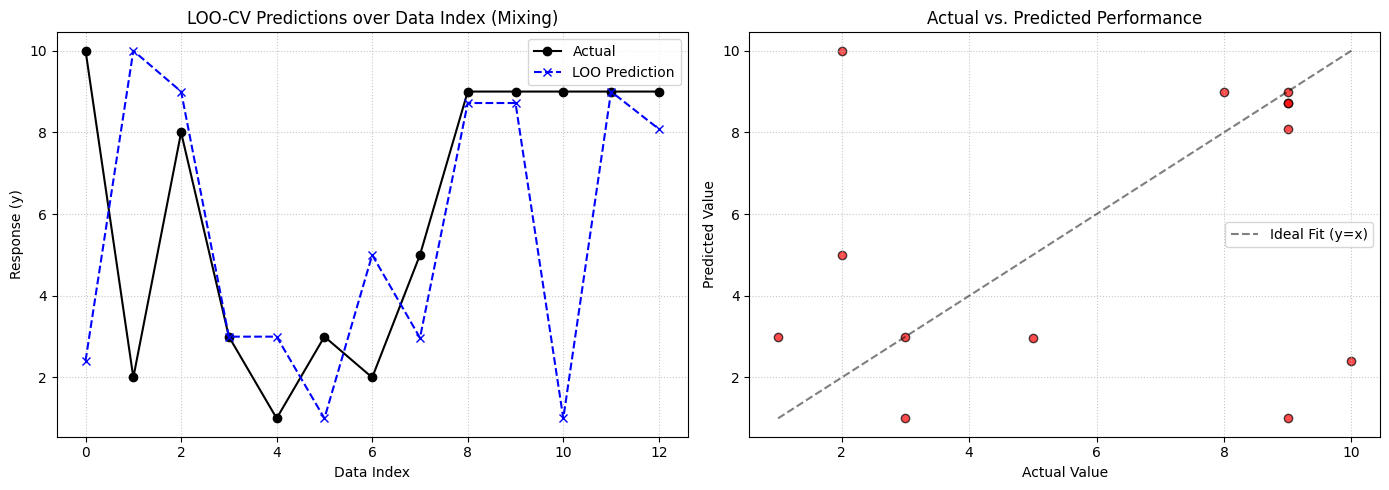

In [99]:
# Execute LOO-CV
preds, rmse, mae, log_like = perform_loo_cv(
    y_data,
    z_data,
    optimal_g_data,
    mixing_method='forecast_mixing',
    solver_method='analytical',
    opt_prior_phi=False,
    verbose=True,
)

# Plot the outcome
plot_loo_validation(y_data, preds, title_suffix="(Mixing)")

Starting Baseline LOO-CV...
Fold  0 | Actual: 10.0000 | Mean:  5.7500 | OLS: 12.5131
Fold  1 | Actual:  2.0000 | Mean:  6.4167 | OLS:  4.6190
Fold  2 | Actual:  8.0000 | Mean:  5.9167 | OLS:  0.1843
Fold  3 | Actual:  3.0000 | Mean:  6.3333 | OLS:  4.6610
Fold  4 | Actual:  1.0000 | Mean:  6.5000 | OLS:  4.8746
Fold  5 | Actual:  3.0000 | Mean:  6.3333 | OLS:  4.1945
Fold  6 | Actual:  2.0000 | Mean:  6.4167 | OLS:  4.2685
Fold  7 | Actual:  5.0000 | Mean:  6.1667 | OLS:  5.8053
Fold  8 | Actual:  9.0000 | Mean:  5.8333 | OLS:  7.2316
Fold  9 | Actual:  9.0000 | Mean:  5.8333 | OLS:  2.9356
Fold 10 | Actual:  9.0000 | Mean:  5.8333 | OLS:  7.1503
Fold 11 | Actual:  9.0000 | Mean:  5.8333 | OLS:  7.1396
Fold 12 | Actual:  9.0000 | Mean:  5.8333 | OLS:  7.1609

--- Baseline Results ---
Mean Baseline -> RMSE: 3.57 | MAE: 3.41
OLS Baseline  -> RMSE: 3.39 | MAE: 2.78


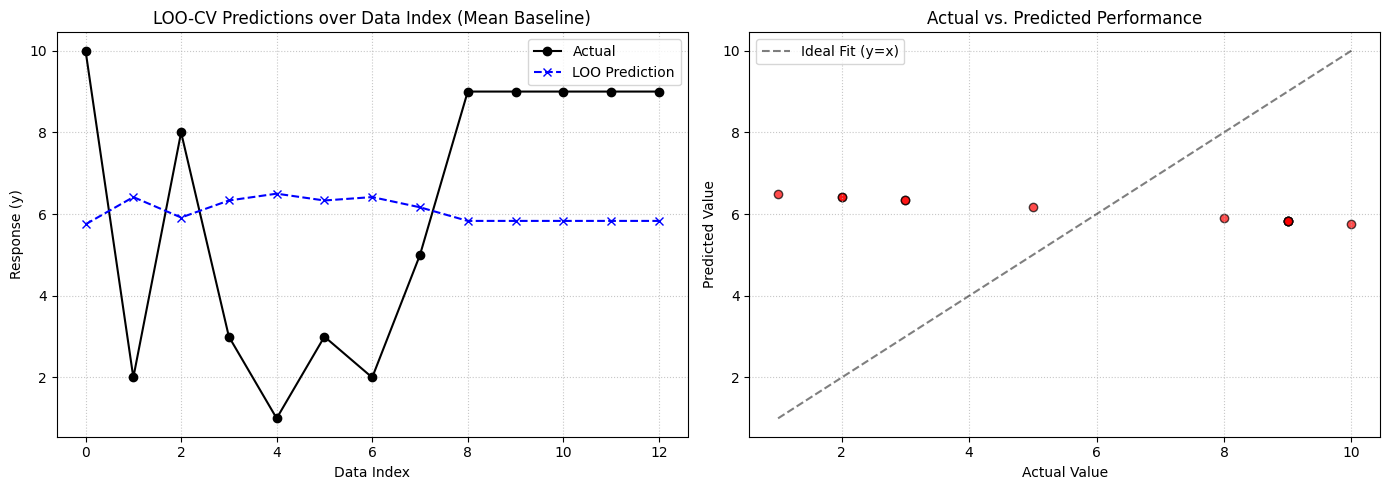

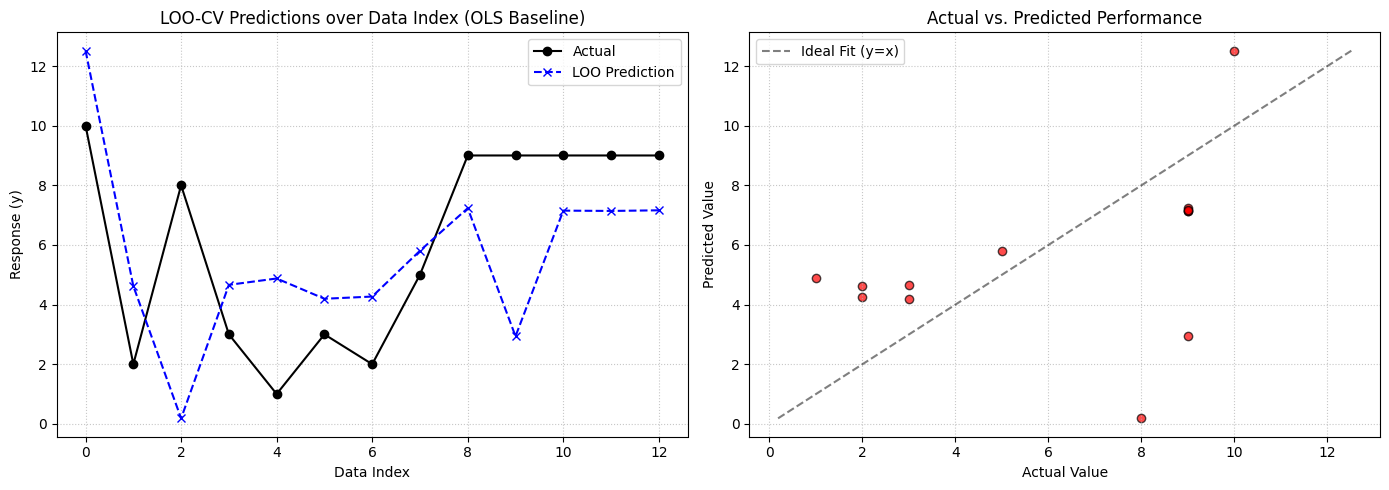

In [100]:
def baseline_loo_cv(y_data, z_data):
    """
    Computes Leave-One-Out predictions for two simple baselines:
    1. Global Mean of N-1 observations
    2. Ordinary Least Squares (OLS) using only continuous regressors (z)
    """
    num_steps = len(y_data)
    mean_preds = np.zeros(num_steps)
    ols_preds = np.zeros(num_steps)

    # Prepare Z matrix for OLS: [Intercept, z1, z2]
    Z_full = np.vstack([np.ones(num_steps), z_data]).T

    print("Starting Baseline LOO-CV...")

    for test_idx in range(num_steps):
        # Slice the N-1 Training Data
        train_mask = np.arange(num_steps) != test_idx
        y_train = y_data[train_mask]
        Z_train = Z_full[train_mask]

        # Test input
        Z_test = Z_full[test_idx]

        # --- Baseline 1: Simple Mean ---
        mean_preds[test_idx] = np.mean(y_train)

        # --- Baseline 2: OLS Regression ---
        try:
            # theta = (Z^T * Z)^-1 * Z^T * y
            theta_ols = np.linalg.inv(Z_train.T @ Z_train) @ Z_train.T @ y_train
            ols_preds[test_idx] = Z_test @ theta_ols
        except np.linalg.LinAlgError:
            # Fallback to mean if the matrix is completely singular
            ols_preds[test_idx] = np.mean(y_train)

        print(f"Fold {test_idx:2d} | Actual: {y_data[test_idx]:7.4f} | Mean: {mean_preds[test_idx]:7.4f} | OLS: {ols_preds[test_idx]:7.4f}")

    # Compute overall metrics
    mean_rmse = np.sqrt(np.mean((mean_preds - y_data)**2))
    mean_mae = np.mean(np.abs(mean_preds - y_data))

    ols_rmse = np.sqrt(np.mean((ols_preds - y_data)**2))
    ols_mae = np.mean(np.abs(ols_preds - y_data))

    print("\n--- Baseline Results ---")
    print(f"Mean Baseline -> RMSE: {mean_rmse:.2f} | MAE: {mean_mae:.2f}")
    print(f"OLS Baseline  -> RMSE: {ols_rmse:.2f} | MAE: {ols_mae:.2f}")

    return mean_preds, ols_preds

# Execute and compare
mean_preds, ols_preds = baseline_loo_cv(y_data, z_data)

plot_loo_validation(y_data, mean_preds, title_suffix="(Mean Baseline)")
plot_loo_validation(y_data, ols_preds, title_suffix="(OLS Baseline)")